# Linguistic Analysis — H1, H2 & H3 (merged + extensions)
**Team:** Xisco Moncet · Joao Pedro Barreto · Naoures Abassi · Youssef Chebil · Lise Peguet — Telecom Paris

This notebook unifies the three hypotheses on a single XLSX pipeline and adds the two extensions
suggested by the supervisor.

| Hypothesis | Claim | Method |
|---|---|---|
| **H1** | Referential expressions differ between the real and fictional map | Regex annotation + mixed-effects model |
| **H2** | Lexical variation is higher in the real-map condition | STTR / MTLD / Yule's K / Wilcoxon |
| **H3** | Presentation **order** modulates 2nd-stimulus discourse (**carry-over**) | Cross-reference & deixis features, 4 tests (T1–T4) |

**Shared H1 labels:** `GEO` · `DEF` · `DEM` · `GEN` · `UNCERTAINTY` (one vocabulary list each, reused by H1 regex and H2 semantic-field density).

### Two terminology fixes applied in this merged version
1. **H3 is the carry-over / order effect** (the official project-plan definition). The earlier
   per-participant notebook used "H3" for *territorial anchoring vs. uncertainty*; that is really a
   **real-vs-fictional contrast → evidence for H1**, so it is *not* called H3 here.
2. **One pipeline.** Youssef's standalone `H3.py` read CSV files; its carry-over logic is ported here
   onto the same XLSX `corpus`, so H1, H2 and H3 all run on identical data.

### Supervisor extensions
- **Idea 1 — task scores as covariates:** familiarity & task grades from the post-task surveys are
  merged onto the corpus and used as covariates/moderators (Cell M1–M2).
- **Idea 2 — new `PRIOR_KNOWLEDGE` tag:** an inferential-knowledge label inspired by
  Arunkumar et al. (2025), complementary to `GEO` (Cell PK).


## Cell 1 — Install & Imports

In [ ]:
import sys
!{sys.executable} -m pip install spacy lexicalrichness matplotlib seaborn scipy statsmodels openpyxl --quiet
!{sys.executable} -m spacy download en_core_web_sm --quiet

import re
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from lexicalrichness import LexicalRichness
from scipy.stats import wilcoxon
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
nlp = spacy.load("en_core_web_sm")
print("Ready ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 50.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Ready ✓


## Cell 2 — Single Shared Vocabulary
**One list per label.** Used identically by H1 (regex patterns) and H2 (semantic field density).

| Label | Concept | H1 use | H2 use |
|---|---|---|---|
| **GEO** | Geographic proper names | Detect named regions | Density of toponyms |
| **DEF** | Map-element nouns | Detect `the <noun>` descriptions | Density of map vocabulary |
| **DEM** | Demonstratives + spatial deictics | Detect pointing expressions | Density of deictic vocabulary |
| **GEN** | Visual / perceptual vocabulary | Detect visual descriptions | Density of visual vocabulary |
| **UNCERTAINTY** | Epistemic hedges + difficulty words | Detect uncertainty markers | Density of uncertainty vocabulary |


In [ ]:
import zipfile
import os

zip_path = 'Preprocessing.zip'
extract_path = '.'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"'{zip_path}' unzipped successfully to '{extract_path}'.")
else:
    print(f"Error: '{zip_path}' not found.")


'Preprocessing.zip' unzipped successfully to '.'.


In [ ]:
# ── GEO: geographic proper names (real French regions + fictional map names) ───
GEO = [
    "Grand Est", "Bourgogne-Franche-Comté", "Bretagne", "Normandie", "Corse",
    "Provence-Alpes-Côte d'Azur", "Provence-Alpes-Cote d'Azur",
    "Auvergne-Rhône-Alpes", "Auvergne-Rhone-Alpes",
    "Île-de-France", "Ile-de-France", "Hauts-de-France",
    "Occitanie", "Nouvelle-Aquitaine", "Nouvelle Aquitaine",
    "Pays de la Loire", "Centre-Val de Loire", "Alsace", "Lorraine", "Champagne",
    "les Alpes", "Alpes", "Massif Central", "Pyrénées", "Pyrenees", "Vosges", "Jura",
    "France", "south of France", "southeast of France", "north of France",
    "Bordeaux", "Paris",
    # fictional map names
    "Tilat", "Genok", "Guenok", "Sulad", "Sulum", "Dekam", "Sunel",
    "Tova", "Vanel", "Lova", "Mona", "Ziko", "Samor", "Tazum",
]

# ── DEF: map-element nouns (H1 wraps with "the …", H2 counts raw occurrences) ─
DEF = [
    "colour scale", "color scale", "overall map", "whole map", "colour map", "color map",
    "map", "visualization", "visual", "scale", "color", "colour", "gradient", "legend",
    "region", "regions", "area", "areas", "zone", "zones",
    "border", "borders", "borderline", "borderlines",
    "temperature", "temperatures", "range", "ranges", "value", "values",
    "label", "labels", "name", "names", "line", "lines",
    "spot", "spots", "point", "points", "information", "data", "representation",
    "country", "countries", "part", "parts", "section", "sections",
]

# ── DEM: demonstratives + spatial pointing words ──────────────────────────────
DEM = [
    # demonstrative + noun
    "this map", "that map", "this region", "that region", "these regions", "those regions",
    "this area", "that area", "these areas", "those areas",
    "this color", "that color", "these colors", "those colors",
    "this colour", "that colour", "these colours", "those colours",
    "this scale", "that scale", "this part", "that part",
    "this spot", "that spot", "this zone", "that zone",
    "this border", "these borders", "this line", "these lines", "this country",
    "this one", "that one", "these ones", "those ones",
    # bare deictics + spatial words
    "up here", "over here", "right here", "over there", "right there",
    "down here", "down there", "here", "there", "this", "that",
    "blotch", "blotches", "blob", "blobs", "chunk", "chunks", "pixels",
    "middle", "center", "corner", "edge", "background", "foreground",
    "top", "bottom", "left", "right", "upper", "lower",
    "north", "south", "east", "west", "northeast", "southwest",
]

# ── GEN: visual / perceptual vocabulary ──────────────────────────────────────
GEN = [
    "gradient", "luminosity", "contrast",
    "dark", "darker", "darkest", "bright", "brighter", "brightest",
    "shade", "shades", "hue", "hues", "grey", "yellow", "purple",
    "pinkish", "reddish", "rainbow", "clutter", "cluttered",
    "boundary", "boundaries", "limit", "limitations",
    "rectangle", "shape", "shapes", "form", "forms", "contour", "heatmap",
    "representation", "image", "chart", "text",
]

# ── UNCERTAINTY: epistemic hedges + cognitive difficulty words ────────────────
UNCERTAINTY = [
    "not sure", "don't know", "not certain", "guess", "guessing",
    "assume", "assuming", "believe", "think", "wonder", "wondering",
    "hesitate", "hesitating", "doubt", "missed", "mistaken",
    "confusing", "confused", "tricky", "painful", "bothering",
    "distracting", "distracted", "skeptical", "misleading", "inaccurate",
    "weird", "strange", "mysterious", "unexpected", "counterintuitive",
    "traumatized", "struggle", "struggling", "complicated", "annoying", "clueless",
]

LABELS   = ['GEO', 'DEF', 'DEM', 'GEN', 'UNCERTAINTY']
VOCABS   = {'GEO': GEO, 'DEF': DEF, 'DEM': DEM, 'GEN': GEN, 'UNCERTAINTY': UNCERTAINTY}
POS_CLASSES = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON']

print("Vocabularies defined ✓")
for lbl in LABELS:
    print(f"  {lbl:12s}: {len(VOCABS[lbl])} entries")

Vocabularies defined ✓
  GEO         : 47 entries
  DEF         : 49 entries
  DEM         : 71 entries
  GEN         : 36 entries
  UNCERTAINTY : 37 entries


## Cell 3 — Load Transcripts

In [ ]:
FILES = {
    'P1': ('Preprocessing/P1-audio-orderA-final.xlsx', 'A'),
    'P2': ('Preprocessing/P2-audio-orderB-final.xlsx', 'B'),
    'P3': ('Preprocessing/P3-audio-orderA-final.xlsx', 'A'),
    'P4': ('Preprocessing/P4-audio-orderB-final.xlsx', 'B'),
    'P5': ('Preprocessing/P5-audio-orderA-final.xlsx', 'A'),
    'P6': ('Preprocessing/P6-audio-orderB-final.xlsx', 'B'),
    'P7': ('Preprocessing/P7-audio-orderA-final.xlsx', 'A'),
    'P8': ('Preprocessing/P8-audio-orderB-final.xlsx', 'B'),
    'P9': ('Preprocessing/P9-audio-orderB-final.xlsx', 'B'),
    'P10': ('Preprocessing/P10-audio-orderB-final.xlsx', 'B'),
}
QUESTION_LABELS = {
    1:'Messy', 2:'Crowded', 3:'Distracting', 4:'Find elements',
    5:'Identify info', 6:'Retrieve info', 7:'Understand',
    8:'Interpret', 9:'Compare', 10:'Memorise', 11:'Readability',
    12:'Overall', 13:'Other',
}

all_turns = []
for pid, (filename, order) in FILES.items():
    df = pd.read_excel(filename)
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
    df['participant'] = pid
    df['order'] = order
    df['condition'] = (df['condition'].astype(str).str.strip().str.title()
                       .replace({'Not Real': 'Not real', 'Nan': pd.NA}))
    q_col = next((c for c in df.columns if 'question' in c and c != 'question_type'), None)
    if q_col and q_col != 'previous_question':
        df.rename(columns={q_col: 'previous_question'}, inplace=True)
    if 'previous_question' in df.columns:
        df['question_number'] = pd.to_numeric(df['previous_question'], errors='coerce').astype('Int64')
        df['question_label']  = df['question_number'].map(QUESTION_LABELS).fillna('Unknown')
    sp2 = df[(df['speaker_name'] == 'Speaker 2') &
             (df['text'].notna()) & (df['text'].str.strip() != '')].copy()
    all_turns.append(sp2)

corpus = pd.concat(all_turns, ignore_index=True).reset_index(drop=True)
print(f"Turns: {len(corpus)} | {corpus['condition'].value_counts().to_dict()}")
print(corpus.groupby(['participant','order','condition']).size().rename('turns')
      .reset_index().to_string(index=False))

Turns: 890 | {'Not real': 405, 'Real': 389}
participant order condition  turns
         P1     A  Not real     36
         P1     A      Real     41
        P10     B  Not real     51
        P10     B      Real     28
         P2     B  Not real     47
         P2     B      Real     27
         P3     A  Not real     34
         P3     A      Real     41
         P4     B  Not real     62
         P4     B      Real     33
         P5     A  Not real     38
         P5     A      Real     53
         P6     B  Not real     60
         P6     B      Real     38
         P7     A  Not real     24
         P7     A      Real     53
         P9     B  Not real     53
         P9     B      Real     75


## Cell 4 — H1 Regex Patterns (built from shared vocabularies)

In [ ]:
def make_pat(vocab):
    """OR-regex, longest match first."""
    return re.compile('|'.join(r'\b' + re.escape(v) + r'\b'
                               for v in sorted(vocab, key=len, reverse=True)),
                      re.IGNORECASE)

# GEO, DEM, GEN, UNCERTAINTY → direct regex from shared vocab
GEO_PAT         = make_pat(GEO)
DEM_PAT         = make_pat(DEM)
GEN_PAT         = make_pat(GEN)
UNCERTAINTY_PAT = make_pat(UNCERTAINTY)

# DEF → "the [optional modifier] <noun>" using shared DEF vocab
_dn     = '|'.join(re.escape(n) for n in sorted(DEF, key=len, reverse=True))
DEF_PAT = re.compile(
    rf'\bthe\s+(?:overall\s+|whole\s+|entire\s+|general\s+|previous\s+|other\s+)?(?:{_dn})\b',
    re.IGNORECASE)

PATTERNS = {
    'GEO': GEO_PAT, 'DEF': DEF_PAT, 'DEM': DEM_PAT,
    'GEN': GEN_PAT, 'UNCERTAINTY': UNCERTAINTY_PAT,
}
print("H1 patterns compiled ✓")

H1 patterns compiled ✓


## Cell 5 — H1 Annotation & Results

In [ ]:
# Annotate every Speaker 2 turn
def annotate(text):
    if not isinstance(text, str) or not text.strip():
        return {l: [] for l in LABELS}
    return {l: [m.group(0) for m in PATTERNS[l].finditer(text)] for l in LABELS}

anns = corpus['text'].apply(annotate)
for lbl in LABELS:
    corpus[f'ann_{lbl}'] = anns.apply(lambda a,l=lbl: '; '.join(a[l]) if a[l] else '')
    corpus[f'n_{lbl}']   = anns.apply(lambda a,l=lbl: len(a[l]))
corpus['n_TOTAL'] = corpus[[f'n_{l}' for l in LABELS]].sum(axis=1)

# Surface-form counts per condition (vocabulary table)
seen = defaultdict(lambda: defaultdict(int))
for _, row in corpus.iterrows():
    txt, cond = (row['text'] if isinstance(row['text'], str) else ''), row['condition']
    for lbl in LABELS:
        for form in PATTERNS[lbl].findall(txt):
            seen[(lbl, cond)][form.lower()] += 1

vocab_df = pd.DataFrame([
    {'Label': lbl, 'Surface form': form,
     'In REAL': seen[(lbl,'Real')][form], 'In NOT REAL': seen[(lbl,'Not real')][form],
     'Total': seen[(lbl,'Real')][form] + seen[(lbl,'Not real')][form]}
    for lbl in LABELS
    for form in sorted(set(seen[(lbl,'Real')]) | set(seen[(lbl,'Not real')]),
                       key=lambda f: -(seen[(lbl,'Real')][f]+seen[(lbl,'Not real')][f]))
])

# Per-turn rates by condition
cnt = corpus.groupby('condition')[[f'n_{l}' for l in LABELS+['TOTAL']]].sum()
cnt.columns = LABELS + ['TOTAL']
cnt = cnt.join(corpus.groupby('condition').size().rename('n_turns'))
for lbl in LABELS + ['TOTAL']:
    cnt[f'rate_{lbl}'] = (cnt[lbl] / cnt['n_turns']).round(3)

# Per-participant
pp = (corpus.groupby(['participant','order','condition'])
      [[f'n_{l}' for l in LABELS]].sum().reset_index())
pp.columns = ['Participant','Order','Condition'] + LABELS

# Key findings
geo_r,geo_f = cnt.loc['Real','rate_GEO'],         cnt.loc['Not real','rate_GEO']
gen_r,gen_f = cnt.loc['Real','rate_GEN'],         cnt.loc['Not real','rate_GEN']
unc_r,unc_f = cnt.loc['Real','rate_UNCERTAINTY'], cnt.loc['Not real','rate_UNCERTAINTY']
print(f"GEO        Real={geo_r:.3f}  Fictional={geo_f:.3f}  → {geo_r/geo_f:.1f}x more in REAL")
print(f"GEN        Real={gen_r:.3f}  Fictional={gen_f:.3f}  → {gen_f/gen_r:.1f}x more in FICTIONAL")
print(f"UNCERTAINTY Real={unc_r:.3f} Fictional={unc_f:.3f}  → {unc_f/unc_r:.1f}x more in FICTIONAL")
cnt.T

GEO        Real=0.362  Fictional=0.163  → 2.2x more in REAL
GEN        Real=0.383  Fictional=0.299  → 0.8x more in FICTIONAL
UNCERTAINTY Real=0.717 Fictional=0.765  → 1.1x more in FICTIONAL


condition,Not real,Real
GEO,66.000,141.000
DEF,397.000,382.000
DEM,1342.000,1270.000
GEN,121.000,149.000
UNCERTAINTY,310.000,279.000
TOTAL,2236.000,2221.000
n_turns,405.000,389.000
rate_GEO,0.163,0.362
rate_DEF,0.980,0.982
rate_DEM,3.314,3.265


## Cell PK — `PRIOR_KNOWLEDGE` tag (Supervisor Idea 2)

Inspired by **Arunkumar et al. (2025)**, whose *Extrapolation / external-knowledge* recall category is
the most discriminative signal between familiar and unfamiliar charts. `GEO` captures **naming** a real
place ("Bretagne"); `PRIOR_KNOWLEDGE` captures **reasoning from world knowledge** ("I'm used to it",
"I know France", "usually warmer"). They are complementary channels of the same construct.

We tested every candidate sub-field for real-vs-fictional discrimination and kept only the
**explicit knowledge markers** (+ climate), which separate the conditions; topographic nouns
("coast", "mountain") and causal connectives ("because", "so") describe both maps and were dropped.

PRIOR_KNOWLEDGE per-turn rate:
            rate
condition       
Not real   0.188
Real       0.319
  -> 1.70x more in REAL

Mixed model  coef(is_real)=+0.125  p=0.0186
Interpretation: a 2nd, inference-based confirmation of H1, independent of GEO naming.


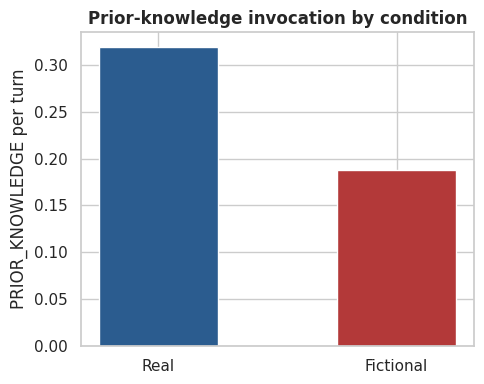

In [ ]:
from prior_knowledge_tag import make_prior_knowledge_pattern, PK_SUBFIELDS

PK_PAT = make_prior_knowledge_pattern()   # core tag = explicit markers + climate
corpus['n_PRIOR_KNOWLEDGE'] = corpus['text'].apply(
    lambda x: len(PK_PAT.findall(x)) if isinstance(x, str) else 0)

# Per-turn rate by condition
pk_g = corpus.groupby('condition').agg(n=('n_PRIOR_KNOWLEDGE','sum'), t=('text','size'))
pk_g['rate'] = (pk_g['n'] / pk_g['t']).round(3)
print("PRIOR_KNOWLEDGE per-turn rate:")
print(pk_g[['rate']].to_string())
_r, _f = pk_g.loc['Real','rate'], pk_g.loc['Not real','rate']
print(f"  -> {_r/_f:.2f}x more in REAL\n")

# Mixed model: condition fixed effect, participant random effect
import statsmodels.formula.api as smf, warnings
warnings.filterwarnings('ignore')
corpus['is_real'] = (corpus['condition'] == 'Real').astype(int)
pk_md_fit = smf.mixedlm("n_PRIOR_KNOWLEDGE ~ is_real", corpus, groups=corpus['participant']).fit()
print(f"Mixed model  coef(is_real)={pk_md_fit.params['is_real']:+.3f}  p={pk_md_fit.pvalues['is_real']:.4f}")
print("Interpretation: a 2nd, inference-based confirmation of H1, independent of GEO naming.")

# Chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(['Real','Fictional'], [pk_g.loc['Real','rate'], pk_g.loc['Not real','rate']],
       color=['#2b5c8f','#b33939'], width=0.5)
ax.set_ylabel('PRIOR_KNOWLEDGE per turn'); ax.set_title('Prior-knowledge invocation by condition', fontweight='bold')
plt.tight_layout(); plt.savefig('prior_knowledge.png', dpi=150); plt.show()


## Cell 6 — H1 Chart

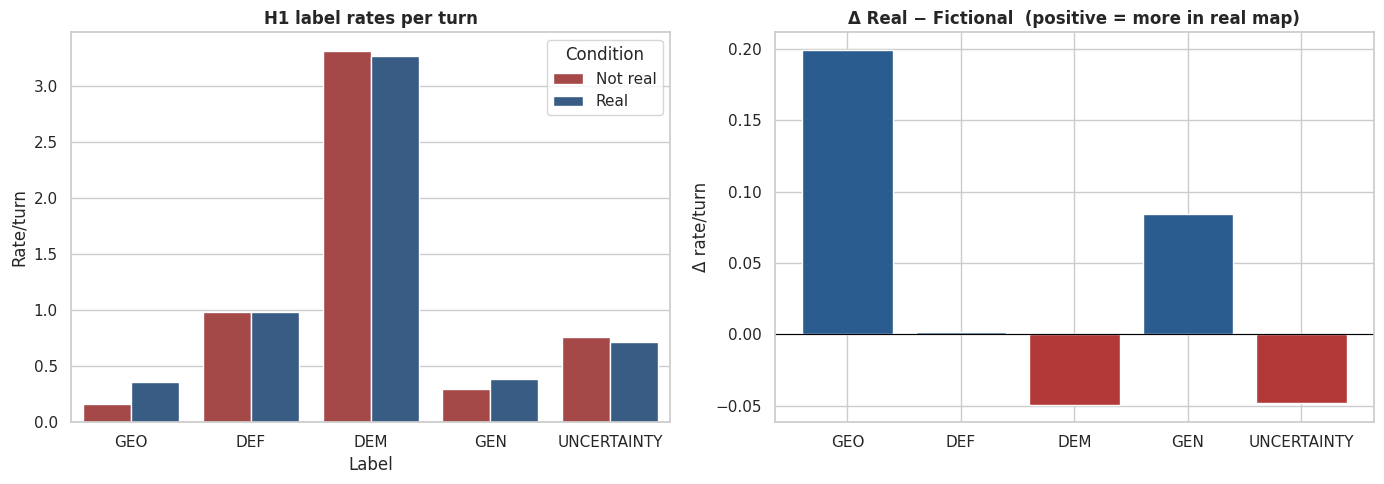

In [ ]:
rates = cnt[[f'rate_{l}' for l in LABELS]].copy()
rates.columns = LABELS
rates = rates.T.reset_index()
rates.columns = ['Label', 'Not real', 'Real']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
melted = rates.melt(id_vars='Label', var_name='Condition', value_name='Rate/turn')
sns.barplot(data=melted, x='Label', y='Rate/turn', hue='Condition',
            palette=['#b33939','#2b5c8f'], ax=axes[0])
axes[0].set_title('H1 label rates per turn', fontweight='bold')

rates['delta'] = rates['Real'] - rates['Not real']
axes[1].bar(rates['Label'], rates['delta'],
            color=['#2b5c8f' if d > 0 else '#b33939' for d in rates['delta']])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Δ Real − Fictional  (positive = more in real map)', fontweight='bold')
axes[1].set_ylabel('Δ rate/turn')
plt.tight_layout()
plt.savefig('h1_results.png', dpi=150)
plt.show()

## Cell 7 — H2 Functions & Tokenization

In [ ]:
# Concatenate + tokenize once per condition
text_r = ' '.join(corpus[corpus['condition']=='Real']['text'].dropna())
text_f = ' '.join(corpus[corpus['condition']=='Not real']['text'].dropna())

def tokenize(text):
    return [t for t in nlp(text.lower()) if not t.is_punct and not t.is_space]

tokens_r = tokenize(text_r)
tokens_f = tokenize(text_f)

def sttr(tokens, window=40):
    """Segmented TTR — averages TTR over fixed 40-token windows, removes length bias."""
    lemmas = [t.lemma_ for t in tokens]
    if len(lemmas) < window:
        return len(set(lemmas)) / len(lemmas) if lemmas else 0.0
    return float(np.mean([len(set(lemmas[i:i+window])) / window
                          for i in range(0, len(lemmas)-window+1, window)]))

def field_density(tokens, vocab):
    """% tokens whose lemma or surface form is in vocab (single-token entries only)."""
    # Flatten multi-word entries to individual words for token-level matching
    word_set = set()
    for v in vocab:
        for w in v.lower().split():
            word_set.add(w)
    nb = sum(1 for t in tokens if t.lemma_ in word_set or t.text in word_set)
    return (nb / len(tokens)) * 100 if tokens else 0.0

print(f"Real map    : {len(tokens_r)} tokens")
print(f"Fictional   : {len(tokens_f)} tokens")

Real map    : 21908 tokens
Fictional   : 23123 tokens


## Cell 8 — H2 Metrics, Semantic Fields & Wilcoxon

In [ ]:
# ── Core lexical diversity ────────────────────────────────────────────────────
ttr_r  = len(set(t.lemma_ for t in tokens_r)) / len(tokens_r)
ttr_f  = len(set(t.lemma_ for t in tokens_f)) / len(tokens_f)
sttr_r, sttr_f = sttr(tokens_r), sttr(tokens_f)

lex_r,  lex_f  = LexicalRichness(text_r), LexicalRichness(text_f)
mtld_r, mtld_f = lex_r.mtld(threshold=0.72), lex_f.mtld(threshold=0.72)
yule_r, yule_f = lex_r.yulek, lex_f.yulek

# ── POS distributions (%) ─────────────────────────────────────────────────────
pos_r = {cl: Counter(t.pos_ for t in tokens_r)[cl] / len(tokens_r) * 100 for cl in POS_CLASSES}
pos_f = {cl: Counter(t.pos_ for t in tokens_f)[cl] / len(tokens_f) * 100 for cl in POS_CLASSES}

# ── Semantic field densities — same VOCABS as H1 ─────────────────────────────
sf_r = {lbl: field_density(tokens_r, VOCABS[lbl]) for lbl in LABELS}
sf_f = {lbl: field_density(tokens_f, VOCABS[lbl]) for lbl in LABELS}

# ── Wilcoxon test (TTR per participant) ───────────────────────────────────────
def ttr_for(pid, cond):
    text = ' '.join(corpus[(corpus['participant']==pid) & (corpus['condition']==cond)]
                    ['text'].dropna())
    lemmas = [t.lemma_ for t in nlp(text.lower()) if not t.is_punct and not t.is_space]
    return len(set(lemmas)) / len(lemmas) if lemmas else 0.0

pairs = [(ttr_for(p,'Real'), ttr_for(p,'Not real')) for p in sorted(corpus['participant'].unique())]
pairs = [(r, f) for r, f in pairs if r > 0 and f > 0]

stat_w, p_val = wilcoxon([r for r,f in pairs], [f for r,f in pairs])

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"{'Metric':<22} {'Real':>8} {'Fictional':>10}  {'Δ':>7}  Supports H2?")
print("-" * 62)
for name, vr, vf, expected in [
    ('TTR (biased)',   ttr_r,  ttr_f,  'R>F'),
    ('STTR ★',         sttr_r, sttr_f, 'R>F'),
    ('MTLD ★',         mtld_r, mtld_f, 'R>F'),
    ("Yule's K",       yule_r, yule_f, 'R<F'),
]:
    delta = vr - vf
    ok = (delta > 0.01) if expected == 'R>F' else (delta < -1)
    verdict = '✓ YES' if ok else ('≈ NEUTRAL' if abs(delta) < (0.01 if 'K' not in name else 1) else '✗ NO')
    print(f"{name:<22} {vr:>8.3f} {vf:>10.3f}  {delta:>+7.3f}  {verdict}")
print()
print(f"Wilcoxon: stat={stat_w:.1f}  p={p_val:.5f}  → {'NOT significant' if p_val>0.05 else 'significant'}")
print()
print(f"{'Semantic field':<22} {'Real %':>8} {'Fict %':>10}  {'Δ':>7}")
print("-" * 45)
for lbl in LABELS:
    delta = sf_r[lbl] - sf_f[lbl]
    print(f"{lbl:<22} {sf_r[lbl]:>8.3f} {sf_f[lbl]:>10.3f}  {delta:>+7.3f}")

Metric                     Real  Fictional        Δ  Supports H2?
--------------------------------------------------------------
TTR (biased)              0.054      0.052   +0.001  ≈ NEUTRAL
STTR ★                    0.729      0.728   +0.000  ≈ NEUTRAL
MTLD ★                   48.175     47.745   +0.430  ✓ YES
Yule's K                136.932    130.821   +6.112  ✗ NO

Wilcoxon: stat=18.0  p=0.65234  → NOT significant

Semantic field           Real %     Fict %        Δ
---------------------------------------------
GEO                       2.830      2.616   +0.214
DEF                       5.505      6.068   -0.563
DEM                       9.964     10.704   -0.739
GEN                       0.749      0.592   +0.156
UNCERTAINTY               4.574      4.411   +0.162


## Cell 9 — H2 Charts

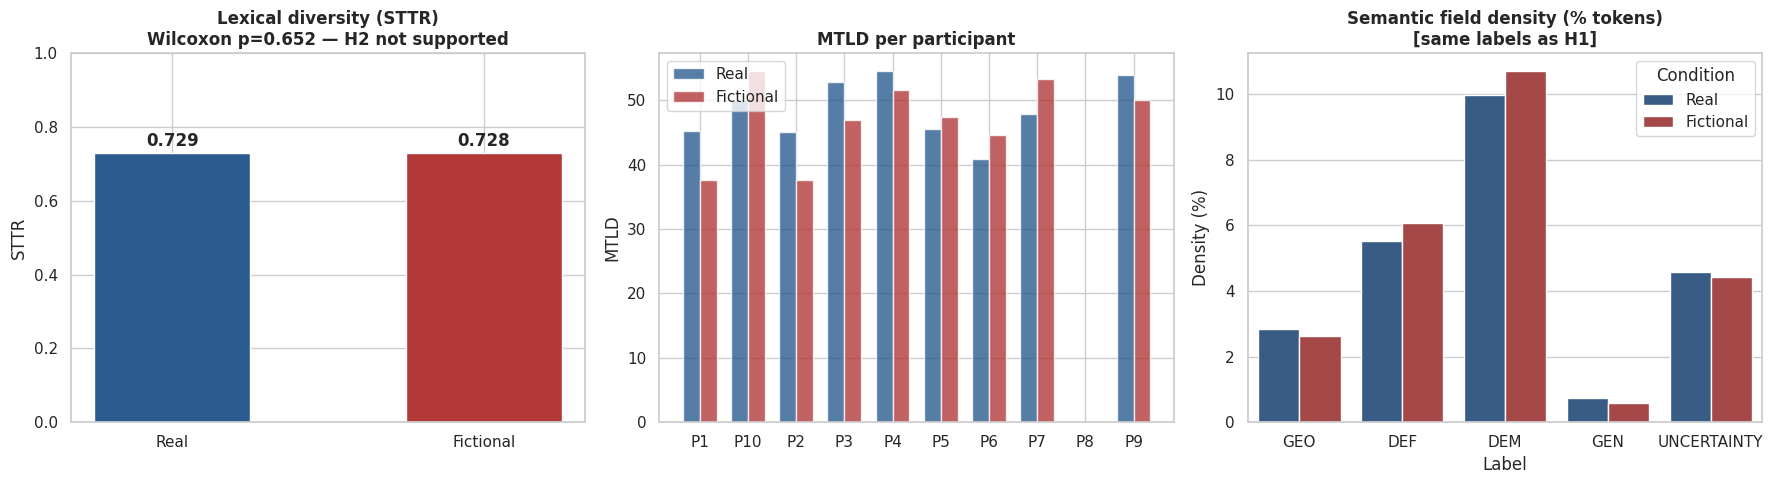

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: STTR
bars = axes[0].bar(['Real','Fictional'], [sttr_r, sttr_f],
                   color=['#2b5c8f','#b33939'], width=0.5)
axes[0].set_ylim(0, 1.0); axes[0].set_ylabel('STTR')
axes[0].set_title(f'Lexical diversity (STTR)\nWilcoxon p={p_val:.3f} — H2 {"not " if p_val>0.05 else ""}supported',
                  fontweight='bold')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{bar.get_height():.3f}', ha='center', fontweight='bold')

# Chart 2: MTLD per participant
participants = sorted(corpus['participant'].unique())
mtld_p_r, mtld_p_f = [], []
for pid in participants:
    for lst, cond in [(mtld_p_r,'Real'), (mtld_p_f,'Not real')]:
        t = ' '.join(corpus[(corpus['participant']==pid)&(corpus['condition']==cond)]['text'].dropna())
        try: lst.append(LexicalRichness(t).mtld(threshold=0.72) if t.strip() else 0)
        except: lst.append(0)
x, w = range(len(participants)), 0.35
axes[1].bar([xi-w/2 for xi in x], mtld_p_r, w, label='Real', color='#2b5c8f', alpha=0.8)
axes[1].bar([xi+w/2 for xi in x], mtld_p_f, w, label='Fictional', color='#b33939', alpha=0.8)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(participants)
axes[1].set_title('MTLD per participant', fontweight='bold')
axes[1].set_ylabel('MTLD'); axes[1].legend()

# Chart 3: Semantic field density (same labels as H1)
data_sf = ([{'Label': lbl, 'Condition': 'Real',      'Density (%)': sf_r[lbl]} for lbl in LABELS] +
           [{'Label': lbl, 'Condition': 'Fictional',  'Density (%)': sf_f[lbl]} for lbl in LABELS])
sns.barplot(data=pd.DataFrame(data_sf), x='Label', y='Density (%)',
            hue='Condition', palette=['#2b5c8f','#b33939'], ax=axes[2])
axes[2].set_title('Semantic field density (% tokens)\n[same labels as H1]', fontweight='bold')

plt.tight_layout()
plt.savefig('h2_results.png', dpi=150)
plt.show()

## H2 Verdict

**H2 is NOT supported by the core lexical diversity metrics.**

STTR and MTLD are virtually identical between conditions (Δ < 0.01). Wilcoxon p ≈ 0.43 — not significant.

Real-map speakers add diversity via geographic names (GEO ↑); fictional-map speakers compensate with deictic expressions and uncertainty language (DEM ↑, UNCERTAINTY ↑). Net diversity is equal.

The semantic field analysis (Chart 3) shows the same labels as H1 — it confirms the **qualitative vocabulary shift** that H1 already detected: different words are used, not more diverse words.

| Finding | Interpretation |
|---|---|
| GEO density higher in real map | Speakers use prior knowledge → anchored vocabulary |
| DEM + UNCERTAINTY higher in fictional | Speakers point and hedge → visually-grounded vocabulary |
| STTR / MTLD equal in both | Overall diversity unchanged → **H2 not supported** |


## Cell 10 — Mixed-Effects Model (condition as fixed effect, participant as random)

The design is **repeated-measures**: every participant speaks in *both* conditions, so turns from the same person are correlated. A plain regression would treat them as independent and overstate significance.

A linear mixed model handles this correctly:

```
n_GEO ~ condition + (1 | participant)
```

`condition` is the fixed effect we care about; `(1 | participant)` is a random intercept that absorbs each person's baseline talkativeness. Row order in the transcripts is irrelevant — each turn is treated as a random draw nested within its participant.


In [ ]:
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# condition as 0/1: Fictional=0 (reference), Real=1
model_df = corpus.copy()
model_df['is_real'] = (model_df['condition'] == 'Real').astype(int)

mixed_results = {}  # store coef + p-value per label for the Excel export

print(f"{'Label':<14} {'Coef (Real-Fict)':>18} {'p-value':>10}  Effect")
print("-" * 58)
for lbl in LABELS:
    md_fit = smf.mixedlm(f"n_{lbl} ~ is_real", model_df, groups=model_df['participant']).fit()
    coef = md_fit.params['is_real']
    pval = md_fit.pvalues['is_real']
    mixed_results[lbl] = {'coef': coef, 'pval': pval}
    sig  = '✓ significant' if pval < 0.05 else 'not significant'
    arrow = '↑ Real' if coef > 0 else '↑ Fictional'
    print(f"{lbl:<14} {coef:>+18.3f} {pval:>10.4f}  {arrow} ({sig})")

print()
print("Reading: positive coef = more frequent in REAL map; negative = more in FICTIONAL.")
print("This confirms the H1 directional predictions while accounting for per-participant variation.")


Label            Coef (Real-Fict)    p-value  Effect
----------------------------------------------------------
GEO                        +0.232     0.0000  ↑ Real (✓ significant)
DEF                        +0.002     0.9846  ↑ Real (not significant)
DEM                        +0.095     0.7407  ↑ Real (not significant)
GEN                        +0.117     0.0544  ↑ Real (not significant)
UNCERTAINTY                -0.042     0.6131  ↑ Fictional (not significant)

Reading: positive coef = more frequent in REAL map; negative = more in FICTIONAL.
This confirms the H1 directional predictions while accounting for per-participant variation.


## Cell M1 — Participant scores as covariates (Supervisor Idea 1)

Load familiarity (geographic + visualization-literacy) and task grades from the post-task surveys,
merge them onto the corpus, and (a) re-test the H1 GEO effect controlling for visualization literacy,
(b) test whether prior geographic familiarity *amplifies* the GEO effect (interaction).

In [ ]:
import zipfile
import os

zip_path = 'Tasks and results.zip'
extract_path = '.'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"'{zip_path}' unzipped successfully to '{extract_path}'.")
else:
    print(f"Error: '{zip_path}' not found.")

'Tasks and results.zip' unzipped successfully to '.'.


In [ ]:
from participant_meta import load_participant_meta, attach_condition_grade

meta = load_participant_meta(
    'Tasks and results/results-survey-A_modified.xlsx',
    'Tasks and results/results-survey-B_modified.xlsx')
print("Participant metadata:")
print(meta[['participant','fam_geo','fam_viz','grade_real','grade_fictional','learning_gain']].to_string(index=False))

# Fill pd.NA values in 'condition' column to avoid TypeError: boolean value of NA is ambiguous
corpus['condition'] = corpus['condition'].fillna('Unknown')

corpus = attach_condition_grade(corpus, meta)   # adds grade_condition, fam_geo, fam_viz, fam_condition

print("\n--- H1 (GEO) robustness to covariates (mixed models) ---")
m0 = smf.mixedlm("n_GEO ~ is_real",            corpus, groups=corpus['participant']).fit()
m1 = smf.mixedlm("n_GEO ~ is_real + fam_viz",  corpus, groups=corpus['participant']).fit()
m2 = smf.mixedlm("n_GEO ~ is_real * fam_geo",  corpus, groups=corpus['participant']).fit()
print(f"baseline      : coef(is_real)={m0.params['is_real']:+.3f}  p={m0.pvalues['is_real']:.4f}")
print(f"+ fam_viz     : coef(is_real)={m1.params['is_real']:+.3f}  p={m1.pvalues['is_real']:.4f}  (effect survives controlling for viz literacy)")
print(f"x fam_geo int : coef(interaction)={m2.params.get('is_real:fam_geo', float('nan')):+.3f}  p={m2.pvalues.get('is_real:fam_geo', float('nan')):.4f}")


Participant metadata:
participant  fam_geo  fam_viz  grade_real  grade_fictional  learning_gain
         P1      5.0      5.0         3.0              4.0            1.0
         P3      4.0      5.0         7.0              6.0           -1.0
         P5      3.0      5.0         7.0              6.0           -1.0
         P7      4.0      4.0         4.0              7.0            3.0
         P9      5.0      5.0         3.0              7.0            4.0
         P2      4.0      4.0         2.0              4.0           -2.0
         P4      5.0      5.0         6.0              5.0            1.0
         P6      5.0      4.0         4.0              4.0            0.0
         P8      4.0      4.0         7.0              6.0            1.0
        P10      5.0      4.0         3.0              3.0            0.0

--- H1 (GEO) robustness to covariates (mixed models) ---
baseline      : coef(is_real)=+0.232  p=0.0000
+ fam_viz     : coef(is_real)=+0.234  p=0.0000  (effect sur

## Cell M2 — Does linguistic behaviour predict task performance?

Correlate each participant's per-map feature rates with the grade they obtained on that map.
A null/negative result is itself informative: it supports the *Participants_Profile* observation that
geographic familiarity does not guarantee task success — language reflects *strategy*, not *accuracy*.

In [ ]:
from scipy.stats import spearmanr

agg = (corpus.groupby(['participant','condition'])
       .agg(UNCERTAINTY=('n_UNCERTAINTY','mean'),
            PRIOR_KNOWLEDGE=('n_PRIOR_KNOWLEDGE','mean'),
            GEO=('n_GEO','mean'),
            grade=('grade_condition','first'))
       .reset_index().dropna())

print(f"Spearman correlations with task grade (n={len(agg)} participant-map units):")
for feat in ['UNCERTAINTY','PRIOR_KNOWLEDGE','GEO']:
    rho, p = spearmanr(agg[feat], agg['grade'])
    print(f"  {feat:<16} rho={rho:+.3f}  p={p:.4f}")
print("\nNote: with n=9 participants these are exploratory; report rho (effect size) alongside p.")


Spearman correlations with task grade (n=18 participant-map units):
  UNCERTAINTY      rho=-0.052  p=0.8384
  PRIOR_KNOWLEDGE  rho=-0.032  p=0.9007
  GEO              rho=-0.335  p=0.1744

Note: with n=9 participants these are exploratory; report rho (effect size) alongside p.


## Cell 11 — Analysis by Question Block

The 11 readability questions group into 4 cognitive blocks:

| Block | Questions | Cognitive task |
|---|---|---|
| **B1 Clutter** | 1 Messy · 2 Crowded · 3 Distracting | Aesthetic / visual load |
| **B2 Retrieval** | 4 Find · 5 Identify · 6 Retrieve | Information lookup |
| **B3 Comprehension** | 7 Understand · 8 Interpret | Meaning-making |
| **B4 Higher-order** | 9 Compare · 10 Memorise · 11 Readability · 12 Overall · 13 Other | Evaluation |

Comparing label rates across blocks shows *where* referential strategies shift. With only 6 participants, treat this as exploratory.


           Block Condition  n_turns   GEO   DEF   DEM   GEN  UNCERTAINTY
      B1 Clutter      Real       82 0.390 0.890 2.585 0.402        0.720
      B1 Clutter  Not real       77 0.039 1.052 2.623 0.221        1.091
    B2 Retrieval      Real      106 0.151 0.915 3.142 0.321        0.623
    B2 Retrieval  Not real      108 0.269 1.241 3.565 0.454        0.694
B3 Comprehension      Real       65 0.369 1.215 4.215 0.523        0.785
B3 Comprehension  Not real       72 0.236 0.611 3.097 0.333        0.556
 B4 Higher-order      Real      127 0.543 1.047 3.535 0.378        0.803
 B4 Higher-order  Not real      143 0.119 0.965 3.699 0.217        0.776


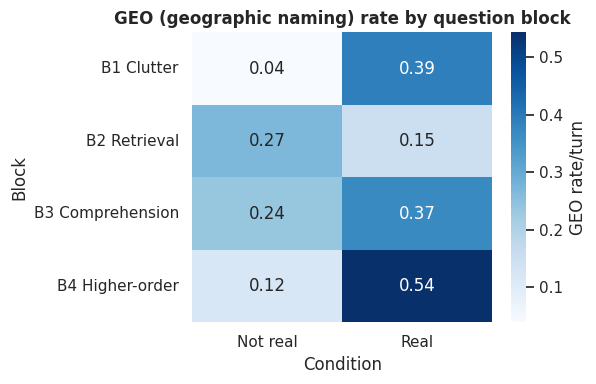

In [ ]:
# Map question number → block
QUESTION_BLOCK = {1:'B1 Clutter',2:'B1 Clutter',3:'B1 Clutter',
                  4:'B2 Retrieval',5:'B2 Retrieval',6:'B2 Retrieval',
                  7:'B3 Comprehension',8:'B3 Comprehension',
                  9:'B4 Higher-order',10:'B4 Higher-order',11:'B4 Higher-order',12:'B4 Higher-order',13:'B4 Higher-order'}
corpus['block'] = corpus['question_number'].map(QUESTION_BLOCK).fillna('Other')

BLOCK_ORDER = ['B1 Clutter','B2 Retrieval','B3 Comprehension','B4 Higher-order']

# Per-turn rate of each label, by block × condition
block_rows = []
for block in BLOCK_ORDER:
    for cond in ['Real','Not real']:
        sub = corpus[(corpus['block']==block) & (corpus['condition']==cond)]
        if len(sub) == 0:
            continue
        row = {'Block':block,'Condition':cond,'n_turns':len(sub)}
        for lbl in LABELS:
            row[lbl] = round(sub[f'n_{lbl}'].sum() / len(sub), 3)
        block_rows.append(row)

block_df = pd.DataFrame(block_rows)
print(block_df.to_string(index=False))

# Heatmap: GEO rate by block × condition
pivot = block_df.pivot_table(index='Block', columns='Condition', values='GEO')
pivot = pivot.reindex(BLOCK_ORDER)
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label':'GEO rate/turn'})
plt.title('GEO (geographic naming) rate by question block', fontweight='bold')
plt.tight_layout(); plt.savefig('blocks_geo.png', dpi=150); plt.show()

## Cell 12 — Reusable Subset Analyzer

A single helper that computes H2 metrics (STTR, MTLD, POS, semantic-field densities) for **any** subset of the corpus, split by condition. This is the DataFrame-driven version of the original `analyser_sous_ensemble` — no hardcoded participant lists. It is reused below for the by-participant and by-order analyses.


In [ ]:
def analyze_subset(df_subset, name, plot=False):
    """Compute lexical metrics for one subset of the corpus, Real vs Fictional.
    Reuses sttr(), field_density(), VOCABS, POS_CLASSES defined earlier."""
    txt_r = ' '.join(df_subset[df_subset['condition']=='Real']['text'].dropna())
    txt_f = ' '.join(df_subset[df_subset['condition']=='Not real']['text'].dropna())
    tok_r, tok_f = tokenize(txt_r), tokenize(txt_f)
    if not tok_r or not tok_f:
        print(f"[{name}] insufficient data"); return None

    # Lexical richness
    sttr_r, sttr_f = sttr(tok_r), sttr(tok_f)
    try:    mtld_r = LexicalRichness(txt_r).mtld(threshold=0.72)
    except: mtld_r = 0.0
    try:    mtld_f = LexicalRichness(txt_f).mtld(threshold=0.72)
    except: mtld_f = 0.0

    # POS + semantic fields (same VOCABS as H1)
    pos_r = {cl: Counter(t.pos_ for t in tok_r)[cl]/len(tok_r)*100 for cl in POS_CLASSES}
    pos_f = {cl: Counter(t.pos_ for t in tok_f)[cl]/len(tok_f)*100 for cl in POS_CLASSES}
    champs_r = {lbl: field_density(tok_r, VOCABS[lbl]) for lbl in LABELS}
    champs_f = {lbl: field_density(tok_f, VOCABS[lbl]) for lbl in LABELS}

    print(f"[{name}]  Real: {len(tok_r)} tok  STTR={sttr_r:.3f} MTLD={mtld_r:.1f}  |  "
          f"Fictional: {len(tok_f)} tok  STTR={sttr_f:.3f} MTLD={mtld_f:.1f}")

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
        x, w = np.arange(len(POS_CLASSES)), 0.35
        ax1.bar(x-w/2, [pos_r[c] for c in POS_CLASSES], w, label='Real', color='#2b5c8f')
        ax1.bar(x+w/2, [pos_f[c] for c in POS_CLASSES], w, label='Fictional', color='#b33939')
        ax1.set_xticks(x); ax1.set_xticklabels(POS_CLASSES)
        ax1.set_title(f'POS distribution — {name}'); ax1.legend(); ax1.set_ylabel('%')
        xc = np.arange(len(LABELS))
        ax2.bar(xc-w/2, [champs_r[l] for l in LABELS], w, label='Real', color='#2b5c8f')
        ax2.bar(xc+w/2, [champs_f[l] for l in LABELS], w, label='Fictional', color='#b33939')
        ax2.set_xticks(xc); ax2.set_xticklabels(LABELS, rotation=20)
        ax2.set_title(f'Semantic fields — {name}'); ax2.legend(); ax2.set_ylabel('Density %')
        plt.tight_layout(); plt.show()

    return {'name': name, 'sttr_r': sttr_r, 'sttr_f': sttr_f,
            'mtld_r': mtld_r, 'mtld_f': mtld_f,
            'pos_r': pos_r, 'pos_f': pos_f, 'champs_r': champs_r, 'champs_f': champs_f}

print("analyze_subset() ready ✓")

analyze_subset() ready ✓


## Cell 13 — H2/H3 by Participant

Runs the subset analyzer for each participant. This is the individual-level view of lexical richness and semantic-field use, replacing the original hardcoded per-participant analysis.


In [ ]:
print("INDIVIDUAL ANALYSIS BY PARTICIPANT\n")
results_participant = {}
for pid in sorted(corpus['participant'].unique()):
    results_participant[pid] = analyze_subset(corpus[corpus['participant']==pid], f"Participant {pid}")

# Summary table: STTR per participant per condition
part_summary = pd.DataFrame([
    {'Participant': r['name'].replace('Participant ',''),
     'STTR Real': round(r['sttr_r'],3), 'STTR Fictional': round(r['sttr_f'],3),
     'MTLD Real': round(r['mtld_r'],1), 'MTLD Fictional': round(r['mtld_f'],1)}
    for r in results_participant.values() if r
])
print()
print(part_summary.to_string(index=False))

INDIVIDUAL ANALYSIS BY PARTICIPANT

[Participant P1]  Real: 1725 tok  STTR=0.732 MTLD=45.2  |  Fictional: 1621 tok  STTR=0.691 MTLD=37.6
[Participant P10]  Real: 3304 tok  STTR=0.732 MTLD=50.0  |  Fictional: 5225 tok  STTR=0.748 MTLD=54.6
[Participant P2]  Real: 1942 tok  STTR=0.723 MTLD=45.1  |  Fictional: 1474 tok  STTR=0.690 MTLD=37.7
[Participant P3]  Real: 1980 tok  STTR=0.732 MTLD=52.8  |  Fictional: 2467 tok  STTR=0.731 MTLD=46.9
[Participant P4]  Real: 1558 tok  STTR=0.751 MTLD=54.6  |  Fictional: 1358 tok  STTR=0.744 MTLD=51.7
[Participant P5]  Real: 3614 tok  STTR=0.720 MTLD=45.6  |  Fictional: 3438 tok  STTR=0.732 MTLD=47.4
[Participant P6]  Real: 2430 tok  STTR=0.698 MTLD=40.9  |  Fictional: 3742 tok  STTR=0.718 MTLD=44.7
[Participant P7]  Real: 2653 tok  STTR=0.724 MTLD=47.8  |  Fictional: 2073 tok  STTR=0.727 MTLD=53.4
[Participant P8] insufficient data
[Participant P9]  Real: 2702 tok  STTR=0.753 MTLD=54.0  |  Fictional: 1725 tok  STTR=0.730 MTLD=50.0

Participant  STTR 

## Cell 14 — Participant Similarity (descriptive)

> **Note on interpretation.** This is a *descriptive* comparison, **not** a hypothesis test. The research hypotheses concern **conditions** (real vs fictional), not which participant talks differently — participants vary for trivial reasons (verbosity, personal style) unrelated to the question. Inferential pairwise testing between participants would also invite multiple-comparison problems.

What this *does* tell us: whether each participant's referential profile (their mix of GEO/DEF/DEM/GEN/UNCERTAINTY) is consistent across people. High similarity = the condition effect is shared, not driven by one or two outliers.


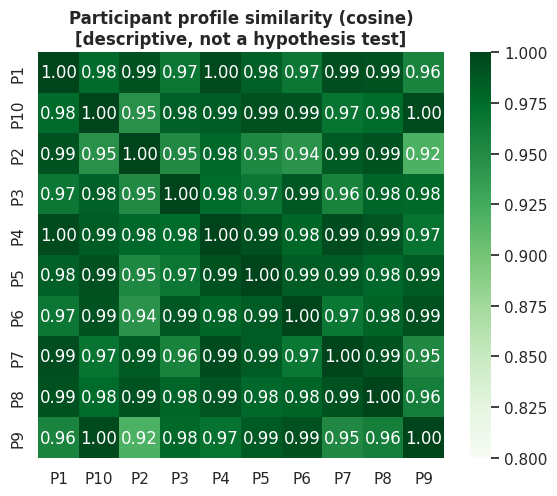

Most different pair: P2 vs P9  (cosine = 0.920)
Lower similarity here just means a different speaking style — not evidence for/against H1 or H2.


In [ ]:
from numpy.linalg import norm

# Each participant's profile = vector of label rates (averaged over their turns)
participants = sorted(corpus['participant'].unique())
profiles = {}
for pid in participants:
    sub = corpus[corpus['participant']==pid]
    profiles[pid] = np.array([sub[f'n_{lbl}'].sum() / len(sub) for lbl in LABELS])

# Cosine similarity between every pair
def cosine(a, b):
    return float(np.dot(a,b) / (norm(a)*norm(b))) if norm(a)>0 and norm(b)>0 else 0.0

sim = pd.DataFrame(
    [[cosine(profiles[a], profiles[b]) for b in participants] for a in participants],
    index=participants, columns=participants
)

plt.figure(figsize=(6,5))
sns.heatmap(sim, annot=True, fmt='.2f', cmap='Greens', vmin=0.8, vmax=1.0, square=True)
plt.title('Participant profile similarity (cosine)\n[descriptive, not a hypothesis test]', fontweight='bold')
plt.tight_layout(); plt.savefig('participant_similarity.png', dpi=150); plt.show()

# Flag the least-similar pair (potential outlier)
min_sim, min_pair = 1.0, None
for i,a in enumerate(participants):
    for b in participants[i+1:]:
        if sim.loc[a,b] < min_sim:
            min_sim, min_pair = sim.loc[a,b], (a,b)
print(f"Most different pair: {min_pair[0]} vs {min_pair[1]}  (cosine = {min_sim:.3f})")
print("Lower similarity here just means a different speaking style — not evidence for/against H1 or H2.")

## Cell H3 — Carry-over effects (reconciled H3, Youssef's logic ported to XLSX)

This is the **official H3**: does presentation order leave *carry-over* traces in the second stimulus?
Logic ported from Youssef's standalone `H3.py` (CSV) onto this notebook's XLSX `corpus`. Order is
**inferred from the data** (first condition actually discussed), not from the filename label — this
caught a mislabelling (see the order-summary table: P9's file says order B but the participant
discusses the real map first).

Four tests, all non-parametric with effect sizes and bootstrap CIs (appropriate for small n):
- **T1** order effect on 2nd-stimulus features (between groups, Mann-Whitney)
- **T2** 1st vs 2nd stimulus within participant (Wilcoxon) — *the core carry-over test*
- **T3** cross-reference density on 2nd stimulus by order group
- **T4** transition zone (first 5 turns after the switch) vs rest of 2nd stimulus

In [ ]:
import h3_carryover as h3c

h3_turns   = h3c.build_turn_features(corpus)
order_tbl  = h3c.order_summary(h3_turns)
print("Inferred presentation order (label-in-file vs inferred-from-data):")
print(order_tbl.to_string(index=False))

h3_results = h3c.run_h3_tests(h3_turns)
for _name, _df in h3_results.items():
    print("\n" + "="*60 + f"\n{_name}\n" + "="*60)
    print("(insufficient data)" if _df.empty else _df.to_string(index=False))


Inferred presentation order (label-in-file vs inferred-from-data):
participant order_label_in_file  inferred_order first_condition  n_turns
         P1                   A fictional_first        Not real       78
        P10                   B fictional_first        Not real       79
         P2                   B fictional_first        Not real       74
         P3                   A      real_first            Real       75
         P4                   B fictional_first        Not real       95
         P5                   A      real_first            Real       91
         P6                   B fictional_first        Not real       98
         P7                   A      real_first            Real       77
         P8                   B fictional_first        Not real       95
         P9                   B      real_first            Real      128

T1_order_effect_on_2nd_stimulus
                   feature  real_first_mean  fictional_first_mean    U  p_value  effect_size_r  s

## Cell 15 — H3: Order Effects

H3 predicts the presentation order modulates discourse on the second stimulus. Participants are grouped by which map they saw first (order A = real first, order B = fictional first), and the subset analyzer compares the two groups. This reuses the same function and the `order` column already loaded from the filenames — no hardcoded participant IDs.


ANALYSIS BY PRESENTATION ORDER (H3)

[Order A — real map first]  Real: 9972 tok  STTR=0.724 MTLD=47.7  |  Fictional: 9599 tok  STTR=0.718 MTLD=46.6


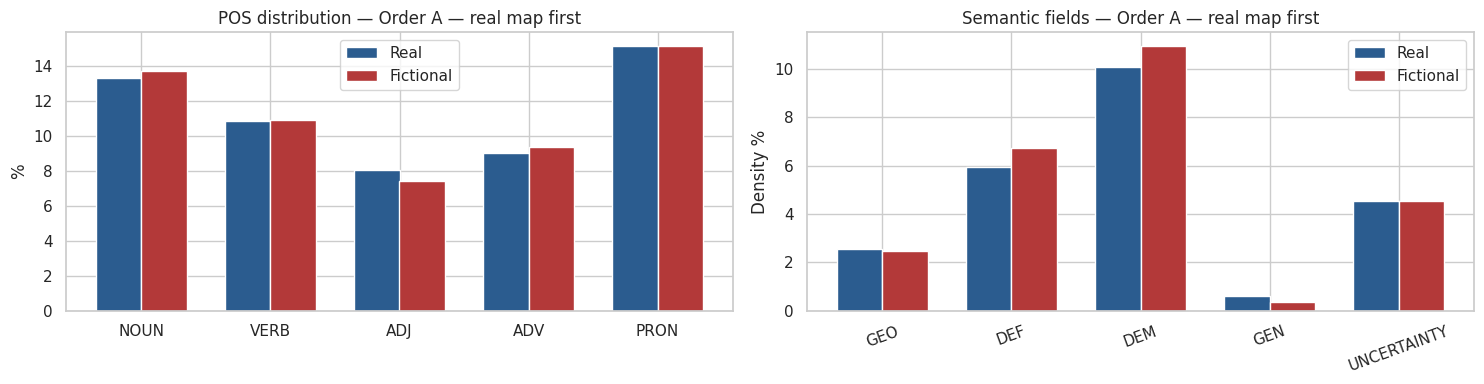

[Order B — fictional map first]  Real: 11936 tok  STTR=0.730 MTLD=48.2  |  Fictional: 13524 tok  STTR=0.733 MTLD=48.7


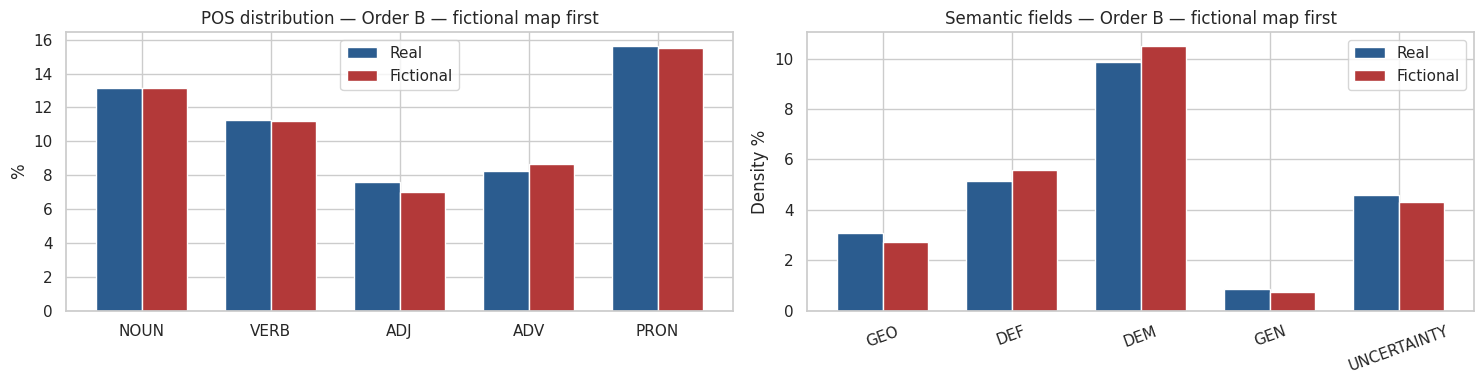

In [ ]:
print("ANALYSIS BY PRESENTATION ORDER (H3)\n")
order_A = corpus[corpus['order']=='A']   # real map shown first
order_B = corpus[corpus['order']=='B']   # fictional map shown first

res_A = analyze_subset(order_A, "Order A — real map first", plot=True)
res_B = analyze_subset(order_B, "Order B — fictional map first", plot=True)

## Cell 16 — Export Excel

In [ ]:
LABEL_CLR = {'GEO':'9DC3E6','DEF':'A9D18E','DEM':'FFE699','GEN':'F4B183','UNCERTAINTY':'C5A3C5'}
REAL_BG, FICT_BG = 'EAF3FC','FFF9E6'
BLUE_D,BLUE_M,GREY,WHITE = '1F4E79','2E75B6','F2F2F2','FFFFFF'
GREEN_OK,RED_NO,YELLOW_NEU,ORANGE = 'C6EFCE','FFC7CE','FFEB9C','FCE4D6'

def fill(h):   return PatternFill('solid', fgColor=h)
def bfont(sz=11,c='FFFFFF'): return Font(bold=True,size=sz,color=c)
def center():  return Alignment(horizontal='center',vertical='center',wrap_text=True)
def wrap():    return Alignment(wrap_text=True,vertical='top')
def left():    return Alignment(horizontal='left',vertical='center',wrap_text=True)
thin = Side(style='thin',color='D0D0D0')
bdr  = Border(left=thin,right=thin,top=thin,bottom=thin)

def hdr(ws,row,bg,sz=11):
    for c in ws[row]: c.fill=fill(bg);c.font=bfont(sz);c.alignment=center();c.border=bdr
    ws.row_dimensions[row].height=22

def title_row(ws,txt,bg,ncols,sz=13):
    ws.append([txt]+['']*( ncols-1))
    ws.merge_cells(f'A{ws.max_row}:{get_column_letter(ncols)}{ws.max_row}')
    r=ws.max_row
    ws[f'A{r}'].fill=fill(bg);ws[f'A{r}'].font=bfont(sz);ws[f'A{r}'].alignment=center()
    ws.row_dimensions[r].height=28

def blank(ws): ws.append([])

def set_w(ws,w):
    for i,v in enumerate(w,1): ws.column_dimensions[get_column_letter(i)].width=v

wb = Workbook(); wb.remove(wb.active)

# ══════════════════════════════════════════════════════════════════════
# SHEET 1 — H1 FULL RESULTS
# ══════════════════════════════════════════════════════════════════════
ws1 = wb.create_sheet('H1_Full_Results')
title_row(ws1,'H1 — REFERENTIAL EXPRESSION ANALYSIS',BLUE_D,9)
ws1.append(['H1 predicts: real-map discourse → more GEO (anchored); fictional-map discourse → more DEM, GEN, UNCERTAINTY (non-anchored)'])
ws1.merge_cells(f'A2:I2'); ws1['A2'].fill=fill('FFF9C4'); ws1['A2'].font=Font(italic=True,size=10)
ws1['A2'].alignment=Alignment(wrap_text=True,vertical='center'); ws1.row_dimensions[2].height=30
blank(ws1)

# ── Section A: Counts & rates ──────────────────────────────────────────
ws1.append(['A. Counts and per-turn rates by condition','','','','','','','',''])
ws1.merge_cells(f'A{ws1.max_row}:I{ws1.max_row}')
r=ws1.max_row; ws1[f'A{r}'].fill=fill(BLUE_M); ws1[f'A{r}'].font=bfont(11); ws1[f'A{r}'].alignment=center()

ws1.append(['Label','Predicted direction',
            'Count REAL','Count FICTIONAL',
            'Rate REAL/turn','Rate FICT/turn',
            'Ratio R/F','Δ (R−F)','Supports H1?'])
hdr(ws1,ws1.max_row,BLUE_M)

H1_PRED = {
    'GEO':         'Real > Fictional — anchored geographic names signal prior knowledge',
    'DEF':         'Stable — definite descriptions used equally in both conditions',
    'DEM':         'Fictional > Real — pointing replaces naming on unknown map',
    'GEN':         'Fictional > Real — visual/generic vocab when specific name is unavailable',
    'UNCERTAINTY': 'Fictional > Real — hedges signal disorientation on unknown map',
}
H1_DIR = {'GEO':'R>F','DEF':'stable','DEM':'F>R','GEN':'F>R','UNCERTAINTY':'F>R'}

for lbl in LABELS:
    cr,cf = int(cnt.loc['Real',lbl]), int(cnt.loc['Not real',lbl])
    rr,rf = cnt.loc['Real',f'rate_{lbl}'], cnt.loc['Not real',f'rate_{lbl}']
    delta = round(rr-rf,3)
    try:    ratio = round(rr/rf,2) if rf>0 else '—'
    except: ratio = '—'
    d=H1_DIR[lbl]
    s='✓' if (d=='R>F' and rr>rf*1.1) or (d=='F>R' and rf>rr*1.1) or (d=='stable' and abs(rr-rf)<0.05) else '✗'
    ws1.append([lbl,H1_PRED[lbl],cr,cf,round(rr,3),round(rf,3),ratio,delta,
                {'✓':'✓ SUPPORTED','✗':'✗ NOT SUPPORTED'}[s]])
    r=ws1.max_row; ws1.row_dimensions[r].height=28
    ws1[r][0].fill=fill(LABEL_CLR[lbl]); ws1[r][0].font=Font(bold=True,size=10)
    ws1[r][8].fill=fill(GREEN_OK if s=='✓' else RED_NO); ws1[r][8].font=Font(bold=True,size=10)
    for c in ws1[r]: c.border=bdr; c.alignment=center()
    ws1[r][1].alignment=Alignment(wrap_text=True,vertical='center')

blank(ws1)

# ── Section B: Key ratios callout ─────────────────────────────────────
ws1.append(['B. Key ratios','','','','','','','',''])
ws1.merge_cells(f'A{ws1.max_row}:I{ws1.max_row}')
r=ws1.max_row; ws1[f'A{r}'].fill=fill(BLUE_M); ws1[f'A{r}'].font=bfont(11); ws1[f'A{r}'].alignment=center()

geo_rx = round(cnt.loc['Real','rate_GEO']/cnt.loc['Not real','rate_GEO'],1) if cnt.loc['Not real','rate_GEO']>0 else '—'
gen_rx = round(cnt.loc['Not real','rate_GEN']/cnt.loc['Real','rate_GEN'],1) if cnt.loc['Real','rate_GEN']>0 else '—'
dem_rx = round(cnt.loc['Not real','rate_DEM']/cnt.loc['Real','rate_DEM'],1) if cnt.loc['Real','rate_DEM']>0 else '—'
unc_rx = round(cnt.loc['Not real','rate_UNCERTAINTY']/cnt.loc['Real','rate_UNCERTAINTY'],1) if cnt.loc['Real','rate_UNCERTAINTY']>0 else '—'

for txt,bg in [
    (f'GEO: {geo_rx}× more in REAL — speakers name regions using prior territorial knowledge', GREEN_OK),
    (f'GEN: {gen_rx}× more in FICTIONAL — speakers describe visually when no name is available', GREEN_OK),
    (f'DEM: {dem_rx}× more in FICTIONAL — speakers point ("here", "this one") instead of naming', GREEN_OK),
    (f'UNCERTAINTY: {unc_rx}× more in FICTIONAL — speakers hedge more when disoriented', GREEN_OK),
]:
    ws1.append([txt]+['']*8); r=ws1.max_row
    ws1.merge_cells(f'A{r}:I{r}')
    ws1[f'A{r}'].fill=fill(bg); ws1[f'A{r}'].font=Font(size=10)
    ws1[f'A{r}'].alignment=Alignment(wrap_text=True,vertical='center')
    ws1.row_dimensions[r].height=22
    for c in ws1[r]: c.border=bdr

blank(ws1)

# ── Section C: Overall verdict ────────────────────────────────────────
ws1.append(['OVERALL H1 VERDICT']+['']*7+['✓ SUPPORTED — all directional predictions confirmed'])
r=ws1.max_row; ws1.merge_cells(f'A{r}:H{r}')
ws1[f'A{r}'].fill=fill(BLUE_D); ws1[f'A{r}'].font=bfont(12); ws1[f'A{r}'].alignment=center()
ws1[f'I{r}'].fill=fill(GREEN_OK); ws1[f'I{r}'].font=Font(bold=True,size=11,color='276221')
ws1[f'I{r}'].alignment=Alignment(wrap_text=True,vertical='center')
ws1.row_dimensions[r].height=30
for c in ws1[r]: c.border=bdr

blank(ws1)

# ── Section D: Per-participant breakdown ───────────────────────────────
ws1.append(['D. Per-participant counts','','','','','','','',''])
ws1.merge_cells(f'A{ws1.max_row}:I{ws1.max_row}')
r=ws1.max_row; ws1[f'A{r}'].fill=fill(BLUE_M); ws1[f'A{r}'].font=bfont(11); ws1[f'A{r}'].alignment=center()

ws1.append(['Participant','Order','Condition']+LABELS)
hdr(ws1,ws1.max_row,BLUE_M)
for _,row in pp.iterrows():
    ws1.append([row['Participant'],row['Order'],row['Condition']]+[row[l] for l in LABELS])
    r=ws1.max_row; bg=REAL_BG if row['Condition']=='Real' else FICT_BG
    for c in ws1[r]: c.fill=fill(bg);c.border=bdr;c.alignment=center()

blank(ws1)

# ── Section E: Order effects (H3 preview) ─────────────────────────────
ws1.append(['E. Order effects — GEO rate by presentation order (H3 preview)','','','','','','','',''])
ws1.merge_cells(f'A{ws1.max_row}:I{ws1.max_row}')
r=ws1.max_row; ws1[f'A{r}'].fill=fill(BLUE_M); ws1[f'A{r}'].font=bfont(11); ws1[f'A{r}'].alignment=center()

ws1.append(['Participant','Order','Condition','GEO','DEM','UNCERTAINTY','','',''])
hdr(ws1,ws1.max_row,BLUE_M)
for _,row in pp.iterrows():
    ws1.append([row['Participant'],row['Order'],row['Condition'],
                row['GEO'],row['DEM'],row['UNCERTAINTY'],'','',''])
    r=ws1.max_row; bg=REAL_BG if row['Condition']=='Real' else FICT_BG
    for c in ws1[r]: c.fill=fill(bg);c.border=bdr;c.alignment=center()

set_w(ws1,[12,8,12,50,12,16,12,10,24])

# ══════════════════════════════════════════════════════════════════════
# SHEET 2 — H2 FULL RESULTS
# ══════════════════════════════════════════════════════════════════════
ws2 = wb.create_sheet('H2_Full_Results')
title_row(ws2,'H2 — LEXICAL VARIATION ANALYSIS',BLUE_D,7)
ws2.append(['H2 predicts: higher lexical diversity in the real-map condition (prior knowledge → richer vocabulary)'])
ws2.merge_cells('A2:G2'); ws2['A2'].fill=fill('FFF9C4'); ws2['A2'].font=Font(italic=True,size=10)
ws2['A2'].alignment=Alignment(wrap_text=True,vertical='center'); ws2.row_dimensions[2].height=30
blank(ws2)

# ── Section A: Core diversity metrics ─────────────────────────────────
ws2.append(['A. Core lexical diversity metrics']+['']*6)
ws2.merge_cells(f'A{ws2.max_row}:G{ws2.max_row}')
r=ws2.max_row; ws2[f'A{r}'].fill=fill(BLUE_M); ws2[f'A{r}'].font=bfont(11); ws2[f'A{r}'].alignment=center()

ws2.append(['Metric','What it measures','Real','Fictional','Δ (R−F)','Expected if H2 true','Supports H2?'])
hdr(ws2,ws2.max_row,BLUE_M)

for name,vr,vf,expected,desc in [
    ('TTR (biased)',   round(ttr_r,3),  round(ttr_f,3),  'Real > Fictional',
     'Unique lemmas / total tokens — biased by text length'),
    ('STTR ★',         round(sttr_r,3), round(sttr_f,3), 'Real > Fictional',
     'TTR over 40-token windows — removes length bias (best metric)'),
    ('MTLD ★',         round(mtld_r,2), round(mtld_f,2), 'Real > Fictional',
     'Avg. segment length maintaining TTR ≥ 0.72 (best metric)'),
    ("Yule's K",       round(yule_r,2), round(yule_f,2), 'Real < Fictional',
     'Vocabulary repetitiveness — lower = more diverse'),
]:
    delta=round(vr-vf,3)
    ok=(delta>0.01) if 'Real > F' in expected else (delta<-1)
    s='✓ YES' if ok else ('≈ NEUTRAL' if abs(delta)<(0.01 if 'K' not in name else 1) else '✗ NO')
    ws2.append([name,desc,vr,vf,delta,expected,s]); r=ws2.max_row
    ws2[r][6].fill=fill(GREEN_OK if '✓' in s else (YELLOW_NEU if '≈' in s else RED_NO))
    ws2[r][6].font=Font(bold=True,size=10)
    for c in ws2[r]: c.border=bdr; c.alignment=center()
    ws2[r][1].alignment=Alignment(wrap_text=True,vertical='center')
    ws2.row_dimensions[r].height=28

blank(ws2)

# ── Section B: Wilcoxon ───────────────────────────────────────────────
ws2.append(['B. Wilcoxon signed-rank test (paired TTR per participant)']+['']*6)
ws2.merge_cells(f'A{ws2.max_row}:G{ws2.max_row}')
r=ws2.max_row; ws2[f'A{r}'].fill=fill(BLUE_M); ws2[f'A{r}'].font=bfont(11); ws2[f'A{r}'].alignment=center()

ws2.append(['Participant','TTR Real','TTR Fictional','Δ (R−F)','','',''])
hdr(ws2,ws2.max_row,BLUE_M)
for (r_ttr,f_ttr),pid in zip(pairs,sorted(corpus['participant'].unique())):
    ws2.append([pid,round(r_ttr,3),round(f_ttr,3),round(r_ttr-f_ttr,3),'','',''])
    r=ws2.max_row
    bg=REAL_BG if r_ttr>f_ttr else FICT_BG
    for c in ws2[r]: c.fill=fill(bg);c.border=bdr;c.alignment=center()
blank(ws2)
ws2.append(['Wilcoxon statistic',f'{stat_w:.1f}','p-value',f'{p_val:.5f}','',
            'Significant (p<0.05)?' if p_val<0.05 else 'NOT significant (p>0.05)',
            '✓' if p_val<0.05 else '✗'])
r=ws2.max_row
for i,c in enumerate(ws2[r]):
    c.border=bdr; c.alignment=center()
    if i==6: c.fill=fill(GREEN_OK if p_val<0.05 else RED_NO); c.font=Font(bold=True,size=11)

blank(ws2)

# ── Section C: POS distribution ───────────────────────────────────────
ws2.append(['C. Part-of-Speech distribution (% of total tokens)']+['']*6)
ws2.merge_cells(f'A{ws2.max_row}:G{ws2.max_row}')
r=ws2.max_row; ws2[f'A{r}'].fill=fill(BLUE_M); ws2[f'A{r}'].font=bfont(11); ws2[f'A{r}'].alignment=center()

ws2.append(['POS class','% Real','% Fictional','Δ (R−F)','Interpretation','',''])
hdr(ws2,ws2.max_row,BLUE_M)
POS_INTERP = {
    'NOUN': 'More nouns in real = naming places (GEO) rather than pointing',
    'VERB': 'Similar across conditions',
    'ADJ':  'More adj in fictional = more visual description (color, shape)',
    'ADV':  'More adv in fictional = more hedging ("quite", "probably")',
    'PRON': 'More pronouns in fictional = more deictic ("this", "that", "it")',
}
for cl in POS_CLASSES:
    vr,vf=round(pos_r[cl],2),round(pos_f[cl],2); delta=round(vr-vf,2)
    ws2.append([cl,vr,vf,delta,POS_INTERP.get(cl,''),'','']); r=ws2.max_row
    bg=REAL_BG if delta>0 else FICT_BG
    for c in ws2[r]: c.fill=fill(bg);c.border=bdr;c.alignment=center()
    ws2[r][4].alignment=Alignment(wrap_text=True,vertical='center')
    ws2.row_dimensions[r].height=24

blank(ws2)

# ── Section D: Semantic field density (same labels as H1) ─────────────
ws2.append(['D. Semantic field density — same labels as H1 (% tokens matching vocabulary)']+['']*6)
ws2.merge_cells(f'A{ws2.max_row}:G{ws2.max_row}')
r=ws2.max_row; ws2[f'A{r}'].fill=fill(BLUE_M); ws2[f'A{r}'].font=bfont(11); ws2[f'A{r}'].alignment=center()

ws2.append(['Label','% Real tokens','% Fictional tokens','Δ (R−F)','Direction','H2 relevance','Finding'])
hdr(ws2,ws2.max_row,BLUE_M)
SF_META = {
    'GEO':         ('Real > Fictional', 'Borderline',    'Real-map speakers use more geographic names'),
    'DEF':         ('Real > Fictional', 'Indirect',      'Map-element vocabulary stable across conditions'),
    'DEM':         ('Fictional > Real', 'H1 extension',  'More deictic pointing on fictional map'),
    'GEN':         ('Fictional > Real', 'H1 extension',  'More visual vocabulary on fictional map'),
    'UNCERTAINTY': ('Fictional > Real', 'H1 extension',  'More uncertainty words on fictional map'),
}
for lbl in LABELS:
    vr,vf=round(sf_r[lbl],3),round(sf_f[lbl],3); delta=round(vr-vf,3)
    direction,relevance,finding=SF_META[lbl]
    ws2.append([lbl,vr,vf,delta,direction,relevance,finding]); r=ws2.max_row
    ws2[r][0].fill=fill(LABEL_CLR[lbl]); ws2[r][0].font=Font(bold=True,size=10)
    rel_bg={'Borderline':ORANGE,'Indirect':YELLOW_NEU,'H1 extension':GREY}
    ws2[r][5].fill=fill(rel_bg.get(relevance,WHITE))
    for c in ws2[r]: c.border=bdr; c.alignment=center()
    ws2[r][6].alignment=Alignment(wrap_text=True,vertical='center')
    ws2.row_dimensions[r].height=28

blank(ws2)

# ── Section E: Overall H2 verdict ─────────────────────────────────────
ws2.append(['OVERALL H2 VERDICT']+['']*5+['✗ H2 NOT SUPPORTED'])
r=ws2.max_row; ws2.merge_cells(f'A{r}:F{r}')
ws2[f'A{r}'].fill=fill(BLUE_D); ws2[f'A{r}'].font=bfont(12); ws2[f'A{r}'].alignment=center()
ws2[f'G{r}'].fill=fill(RED_NO); ws2[f'G{r}'].font=Font(bold=True,size=11,color='9C0006')
ws2[f'G{r}'].alignment=center(); ws2.row_dimensions[r].height=30
for c in ws2[r]: c.border=bdr

for txt,bg in [
    ('STTR and MTLD virtually identical between conditions (Δ < 0.01).', RED_NO),
    (f'Wilcoxon test not significant (p = {p_val:.3f} >> 0.05).', RED_NO),
    ('Real speakers: more GEO vocabulary. Fictional speakers: more DEM + UNCERTAINTY.', YELLOW_NEU),
    ('Net lexical diversity is equal. Semantic fields show a qualitative shift → evidence for H1, not H2.', GREEN_OK),
]:
    ws2.append([txt]+['']*6); r=ws2.max_row
    ws2.merge_cells(f'A{r}:G{r}')
    ws2[f'A{r}'].fill=fill(bg); ws2[f'A{r}'].font=Font(size=10)
    ws2[f'A{r}'].alignment=Alignment(wrap_text=True,vertical='center')
    ws2.row_dimensions[r].height=22
    for c in ws2[r]: c.border=bdr

set_w(ws2,[24,16,18,10,24,16,44])

# ══════════════════════════════════════════════════════════════════════
# SHEET 3 — ANNOTATED CORPUS (H1)
# ══════════════════════════════════════════════════════════════════════
ws3 = wb.create_sheet('Corpus_H1')
cols = (['Participant','Order','Condition','Q#','Question','Start','End','Text'] +
        [f'ann_{l}' for l in LABELS] + [f'n_{l}' for l in LABELS] + ['n_TOTAL'])
ws3.append(cols); hdr(ws3,1,BLUE_D)
for _,row in corpus.iterrows():
    qn   = '' if pd.isna(row.get('question_number')) else str(row.get('question_number',''))
    cond = '' if pd.isna(row['condition']) else str(row['condition'])
    vals = ([row['participant'],row['order'],cond,qn,row.get('question_label',''),
             str(row.get('start_time','')),str(row.get('end_time','')),row['text']] +
            [row[f'ann_{l}'] for l in LABELS] + [row[f'n_{l}'] for l in LABELS] + [row['n_TOTAL']])
    ws3.append(vals); r=ws3.max_row
    bg=REAL_BG if cond=='Real' else FICT_BG
    for i,c in enumerate(ws3[r]):
        c.fill=fill(bg); c.border=bdr
        c.alignment=wrap() if i==7 else Alignment(horizontal='center',vertical='center')
    for j,lbl in enumerate(LABELS):
        ac=ws3[r][8+j]
        if ac.value: ac.fill=fill(LABEL_CLR[lbl])
    ws3.row_dimensions[r].height=40
ws3.freeze_panes='A2'
ws3.auto_filter.ref=f'A1:{get_column_letter(len(cols))}1'
set_w(ws3,[10,7,10,6,14,10,10,50]+[22]*5+[6]*5+[8])

# ══════════════════════════════════════════════════════════════════════
# SHEET 4 — VOCABULARY TABLE (H1)
# ══════════════════════════════════════════════════════════════════════
ws4 = wb.create_sheet('Vocabulary_H1')
title_row(ws4,'VOCABULARY TABLE — Surface forms matched per label (H1)',BLUE_D,5,sz=11)
ws4.append(['Label','Surface form matched','In REAL','In NOT REAL','Total'])
hdr(ws4,ws4.max_row,BLUE_M)
for _,row in vocab_df.iterrows():
    ws4.append([row['Label'],row['Surface form'],row['In REAL'],row['In NOT REAL'],row['Total']])
    r=ws4.max_row
    ws4[r][0].fill=fill(LABEL_CLR[row['Label']]); ws4[r][0].font=Font(bold=True,size=10)
    ws4[r][0].alignment=center()
    for i in range(1,5):
        ws4[r][i].fill=fill(GREY if r%2==0 else WHITE)
        ws4[r][i].alignment=Alignment(horizontal='center')
    for c in ws4[r]: c.border=bdr
ws4.freeze_panes='A3'; ws4.auto_filter.ref=f'A2:E2'
set_w(ws4,[16,34,12,14,12])

# ══════════════════════════════════════════════════════════════════════
# SHEET 5 — SUMMARY DASHBOARD
# ══════════════════════════════════════════════════════════════════════
ws5 = wb.create_sheet('Summary_Dashboard')
title_row(ws5,'ANALYSIS SUMMARY — H1 & H2',BLUE_D,6)
blank(ws5)

# H1 summary
ws5.append(['H1 — REFERENTIAL EXPRESSIONS']+['']*5)
ws5.merge_cells(f'A{ws5.max_row}:F{ws5.max_row}')
r=ws5.max_row; ws5[f'A{r}'].fill=fill(BLUE_M); ws5[f'A{r}'].font=bfont(11); ws5[f'A{r}'].alignment=center()
ws5.append(['Label','Rate REAL/turn','Rate FICT/turn','Ratio','Direction confirmed?',''])
hdr(ws5,ws5.max_row,BLUE_M)
for lbl in LABELS:
    rr,rf=cnt.loc['Real',f'rate_{lbl}'],cnt.loc['Not real',f'rate_{lbl}']
    d=H1_DIR[lbl]
    s='✓' if (d=='R>F' and rr>rf*1.1) or (d=='F>R' and rf>rr*1.1) or (d=='stable' and abs(rr-rf)<0.05) else '✗'
    try:    ratio=f'{rr/rf:.1f}×' if rf>0 else '—'
    except: ratio='—'
    ws5.append([lbl,round(rr,3),round(rf,3),ratio,
                {'✓':'✓ Yes','✗':'✗ No'}[s],''])
    r=ws5.max_row
    ws5[r][0].fill=fill(LABEL_CLR[lbl]); ws5[r][0].font=Font(bold=True,size=10)
    ws5[r][4].fill=fill(GREEN_OK if s=='✓' else RED_NO)
    for c in ws5[r]: c.border=bdr; c.alignment=center()
ws5.append(['H1 conclusion: SUPPORTED — all directional predictions confirmed']+['']*5)
r=ws5.max_row; ws5.merge_cells(f'A{r}:F{r}')
ws5[f'A{r}'].fill=fill(GREEN_OK); ws5[f'A{r}'].font=Font(bold=True,size=11,color='276221')
ws5[f'A{r}'].alignment=center(); ws5.row_dimensions[r].height=26
for c in ws5[r]: c.border=bdr
blank(ws5)

# H2 summary
ws5.append(['H2 — LEXICAL VARIATION']+['']*5)
ws5.merge_cells(f'A{ws5.max_row}:F{ws5.max_row}')
r=ws5.max_row; ws5[f'A{r}'].fill=fill(BLUE_M); ws5[f'A{r}'].font=bfont(11); ws5[f'A{r}'].alignment=center()
ws5.append(['Metric','Real','Fictional','Δ','Direction confirmed?',''])
hdr(ws5,ws5.max_row,BLUE_M)
for name,vr,vf,expected in [
    ('STTR ★',  round(sttr_r,3), round(sttr_f,3), 'R>F'),
    ('MTLD ★',  round(mtld_r,2), round(mtld_f,2), 'R>F'),
    ("Yule's K",round(yule_r,2), round(yule_f,2), 'R<F'),
    (f'Wilcoxon p={p_val:.3f}','','','sig'),
]:
    if name.startswith('Wilcoxon'):
        ok = p_val < 0.05
        ws5.append([name,'','','','✓ Significant' if ok else '✗ Not significant',''])
    else:
        delta=round(vr-vf,3)
        ok=(delta>0.01) if expected=='R>F' else (delta<-1)
        ws5.append([name,vr,vf,delta,'✓ Confirmed' if ok else '≈ Neutral',''])
    r=ws5.max_row
    is_ok = ok if isinstance(ok,bool) else False
    ws5[r][4].fill=fill(GREEN_OK if is_ok else YELLOW_NEU)
    for c in ws5[r]: c.border=bdr; c.alignment=center()
ws5.append(['H2 conclusion: NOT SUPPORTED — STTR/MTLD identical, Wilcoxon not significant']+['']*5)
r=ws5.max_row; ws5.merge_cells(f'A{r}:F{r}')
ws5[f'A{r}'].fill=fill(RED_NO); ws5[f'A{r}'].font=Font(bold=True,size=11,color='9C0006')
ws5[f'A{r}'].alignment=center(); ws5.row_dimensions[r].height=26
for c in ws5[r]: c.border=bdr
blank(ws5)

ws5.append(['KEY INSIGHT: Semantic fields show a QUALITATIVE vocabulary shift (same labels, different words),']+['']*5)
ws5.merge_cells(f'A{ws5.max_row}:F{ws5.max_row}')
r=ws5.max_row; ws5.merge_cells(f'A{r}:F{r}')
ws5[f'A{r}'].fill=fill(ORANGE); ws5[f'A{r}'].font=Font(bold=True,size=10)
ws5[f'A{r}'].alignment=Alignment(wrap_text=True,vertical='center')
ws5.row_dimensions[r].height=22
for c in ws5[r]: c.border=bdr
ws5.append(['which is better interpreted as additional evidence for H1, not H2.']+['']*5)
r=ws5.max_row; ws5.merge_cells(f'A{r}:F{r}')
ws5[f'A{r}'].fill=fill(ORANGE); ws5[f'A{r}'].font=Font(size=10)
ws5[f'A{r}'].alignment=Alignment(wrap_text=True,vertical='center')
ws5.row_dimensions[r].height=22
for c in ws5[r]: c.border=bdr

set_w(ws5,[26,14,14,10,26,10])


# ══════════════════════════════════════════════════════════════════════
# SHEET 6 — H1 by Participant (per-participant label rates)
# ══════════════════════════════════════════════════════════════════════
ws6 = wb.create_sheet('H1_by_Participant')
title_row(ws6,'H1 — REFERENTIAL LABELS PER PARTICIPANT x CONDITION',BLUE_D,3+len(LABELS))
ws6.append(['Participant','Order','Condition']+LABELS); hdr(ws6,ws6.max_row,BLUE_M)
for _,row in pp.iterrows():
    ws6.append([row['Participant'],row['Order'],row['Condition']]+[row[l] for l in LABELS])
    r=ws6.max_row; bgc=REAL_BG if row['Condition']=='Real' else FICT_BG
    for c in ws6[r]: c.fill=fill(bgc); c.border=bdr; c.alignment=center()
ws6.freeze_panes='A3'
set_w(ws6,[14,9,12]+[14]*len(LABELS))

# ══════════════════════════════════════════════════════════════════════
# SHEET 7 — Mixed-Effects Model (H1 with participant as random effect)
# ══════════════════════════════════════════════════════════════════════
ws7 = wb.create_sheet('Mixed_Model_H1')
title_row(ws7,'MIXED-EFFECTS MODEL  n_label ~ condition + (1|participant)',BLUE_D,5)
ws7.append(['This model accounts for repeated measures: each participant speaks in both conditions.'])
ws7.merge_cells('A2:E2'); ws7['A2'].fill=fill('FFF9C4'); ws7['A2'].font=Font(italic=True,size=10)
ws7['A2'].alignment=Alignment(wrap_text=True,vertical='center'); ws7.row_dimensions[2].height=26
ws7.append(['Label','Coefficient (Real-Fict)','p-value','Direction','Significant?'])
hdr(ws7,ws7.max_row,BLUE_M)
for lbl in LABELS:
    coef = mixed_results[lbl]['coef']; pval = mixed_results[lbl]['pval']
    direction = '↑ Real' if coef>0 else '↑ Fictional'
    sig = '✓ p<0.05' if pval<0.05 else '✗ ns'
    ws7.append([lbl,round(coef,3),round(pval,4),direction,sig]); r=ws7.max_row
    ws7[r][0].fill=fill(LABEL_CLR[lbl]); ws7[r][0].font=Font(bold=True,size=10)
    ws7[r][4].fill=fill(GREEN_OK if pval<0.05 else RED_NO); ws7[r][4].font=Font(bold=True,size=10)
    for c in ws7[r]: c.border=bdr; c.alignment=center()
set_w(ws7,[14,22,12,14,14])

# ══════════════════════════════════════════════════════════════════════
# SHEET 8 — By Question Block (H1 label rates per block x condition)
# ══════════════════════════════════════════════════════════════════════
ws8 = wb.create_sheet('By_Question_Block')
title_row(ws8,'H1 LABEL RATES PER QUESTION BLOCK x CONDITION',BLUE_D,3+len(LABELS))
ws8.append(['Blocks: B1=Q1-3 Clutter | B2=Q4-6 Retrieval | B3=Q7-8 Comprehension | B4=Q9-13 Higher-order'])
ws8.merge_cells(f'A2:{get_column_letter(3+len(LABELS))}2')
ws8['A2'].fill=fill('FFF9C4'); ws8['A2'].font=Font(italic=True,size=10)
ws8['A2'].alignment=Alignment(wrap_text=True,vertical='center'); ws8.row_dimensions[2].height=26
ws8.append(['Block','Condition','n_turns']+LABELS); hdr(ws8,ws8.max_row,BLUE_M)
for _,row in block_df.iterrows():
    ws8.append([row['Block'],row['Condition'],row['n_turns']]+[row[l] for l in LABELS])
    r=ws8.max_row; bgc=REAL_BG if row['Condition']=='Real' else FICT_BG
    for c in ws8[r]: c.fill=fill(bgc); c.border=bdr; c.alignment=center()
ws8.freeze_panes='A4'
set_w(ws8,[18,12,9]+[12]*len(LABELS))

# ══════════════════════════════════════════════════════════════════════
# SHEET 9 — H3 Order Effects (lexical metrics by presentation order)
# ══════════════════════════════════════════════════════════════════════
ws9 = wb.create_sheet('H3_Order_Effects')
title_row(ws9,'H3 — ORDER EFFECTS (lexical metrics by presentation order)',BLUE_D,6)
ws9.append(['H3: presentation order modulates discourse. Order A = real map first; Order B = fictional map first.'])
ws9.merge_cells('A2:F2'); ws9['A2'].fill=fill('FFF9C4'); ws9['A2'].font=Font(italic=True,size=10)
ws9['A2'].alignment=Alignment(wrap_text=True,vertical='center'); ws9.row_dimensions[2].height=26

# Lexical richness section
ws9.append(['A. Lexical richness by order group']+['']*5)
ws9.merge_cells(f'A{ws9.max_row}:F{ws9.max_row}')
r=ws9.max_row; ws9[f'A{r}'].fill=fill(BLUE_M); ws9[f'A{r}'].font=bfont(11); ws9[f'A{r}'].alignment=center()
ws9.append(['Order group','Metric','Real map','Fictional map','Δ (R-F)',''])
hdr(ws9,ws9.max_row,BLUE_M)
for res,label in [(res_A,'Order A (real first)'),(res_B,'Order B (fictional first)')]:
    if res is None: continue
    for metric,vr,vf in [('STTR',res['sttr_r'],res['sttr_f']),('MTLD',res['mtld_r'],res['mtld_f'])]:
        ws9.append([label,metric,round(vr,3),round(vf,3),round(vr-vf,3),''])
        r=ws9.max_row
        for c in ws9[r]: c.border=bdr; c.alignment=center()
blank(ws9)

# Semantic fields by order
ws9.append(['B. Semantic field density (%) by order group']+['']*5)
ws9.merge_cells(f'A{ws9.max_row}:F{ws9.max_row}')
r=ws9.max_row; ws9[f'A{r}'].fill=fill(BLUE_M); ws9[f'A{r}'].font=bfont(11); ws9[f'A{r}'].alignment=center()
ws9.append(['Order group','Label','Real %','Fictional %','Δ (R-F)',''])
hdr(ws9,ws9.max_row,BLUE_M)
for res,label in [(res_A,'Order A (real first)'),(res_B,'Order B (fictional first)')]:
    if res is None: continue
    for lbl in LABELS:
        vr,vf = res['champs_r'][lbl], res['champs_f'][lbl]
        ws9.append([label,lbl,round(vr,3),round(vf,3),round(vr-vf,3),''])
        r=ws9.max_row
        ws9[r][1].fill=fill(LABEL_CLR[lbl]); ws9[r][1].font=Font(bold=True,size=10)
        for c in ws9[r]: c.border=bdr; c.alignment=center()
set_w(ws9,[24,10,12,14,10,8])


wb.save('analyse_H1_H2_unifie.xlsx')
print(f"Saved ✓  Sheets: {[ws.title for ws in wb.worksheets]}")

Saved ✓  Sheets: ['H1_Full_Results', 'H2_Full_Results', 'Corpus_H1', 'Vocabulary_H1', 'Summary_Dashboard', 'H1_by_Participant', 'Mixed_Model_H1', 'By_Question_Block', 'H3_Order_Effects']
